# Survey Analysis, Part 1: Descriptive Results

This notebook turns a raw survey export into a complete set of labelled summary tables and charts, exported to a single Excel workbook for reporting.

The design principle: **one reusable function per question type**, not one block of code per question. A typical survey has dozens of questions in only three shapes (single choice, multi-select, Likert matrix), so three small functions cover the whole instrument and any future survey with the same shapes.

> **Note on data:** all data is synthetic and generated for demonstration. It mirrors the structure of a real provider survey I analyzed professionally but contains no real respondents or results.

## 1. Load and filter to completed surveys

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/synthetic_survey_responses.csv')

completed = df[df['COMPLETED'] == 1].copy()
print(f"Total records: {len(df)}  |  Completed surveys: {len(completed)}")

Total records: 412  |  Completed surveys: 385


## 2. Single-choice questions

One function handles every single-choice question: map the coded values to labels, count, calculate percentages, preserve the questionnaire's response order, and plot.

In [2]:
def summarize_single_choice(data, column, labels, title):
    """Summarize a single-choice question: labelled counts, percentages, and a chart."""
    order = list(labels.values())
    series = data[column].map(labels)

    summary = series.value_counts(dropna=False).reindex(order).fillna(0).astype(int).to_frame('Count')
    summary['Percentage'] = (summary['Count'] / summary['Count'].sum()).round(3)
    summary.index.name = title

    fig, ax = plt.subplots(figsize=(8, 3.5))
    summary['Count'].plot.barh(color='#3B3B3B', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Respondents')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return summary.reset_index()

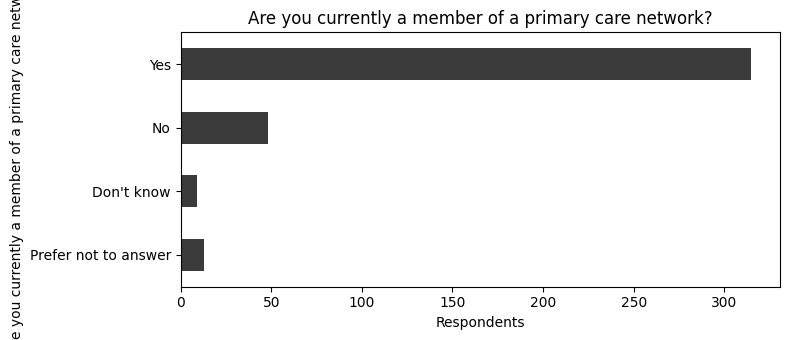

,Are you currently a member of a primary care network?,Count,Percentage
0,Yes,315,0.818
1,No,48,0.125
2,Don't know,9,0.023
3,Prefer not to answer,13,0.034


In [3]:
member_summary = summarize_single_choice(
    completed, 'MEMBER',
    {1: 'Yes', 2: 'No', 88: "Don't know", 99: 'Prefer not to answer'},
    'Are you currently a member of a primary care network?')
member_summary

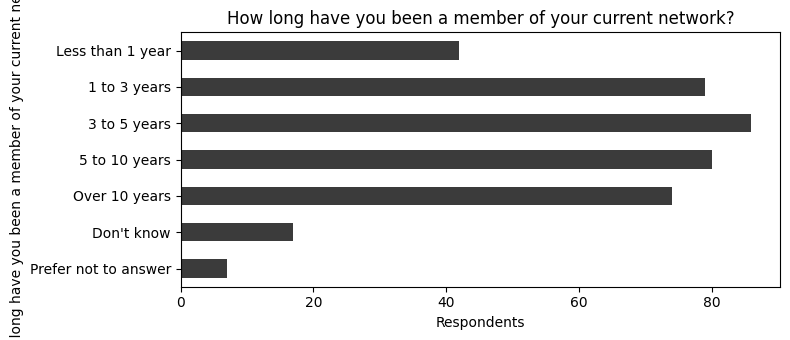

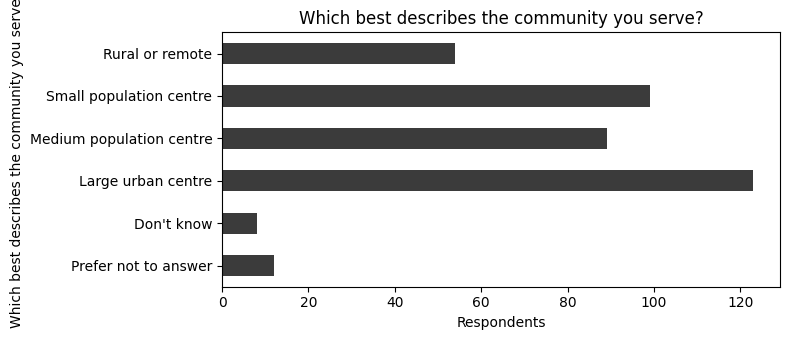

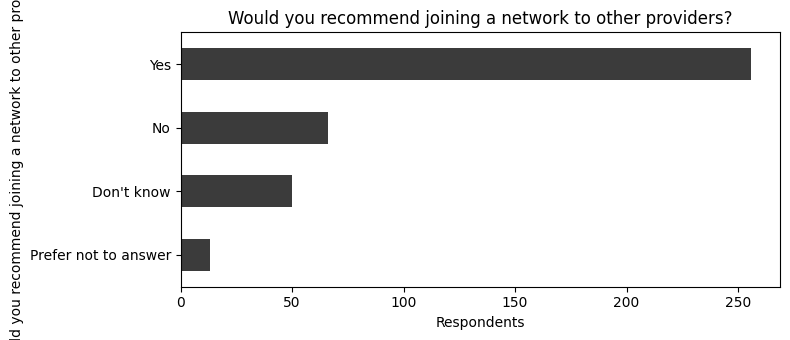

In [4]:
tenure_summary = summarize_single_choice(
    completed, 'TENURE',
    {1: 'Less than 1 year', 2: '1 to 3 years', 3: '3 to 5 years',
     4: '5 to 10 years', 5: 'Over 10 years', 88: "Don't know", 99: 'Prefer not to answer'},
    'How long have you been a member of your current network?')

community_summary = summarize_single_choice(
    completed, 'COMMUNITY_TYPE',
    {1: 'Rural or remote', 2: 'Small population centre', 3: 'Medium population centre',
     4: 'Large urban centre', 88: "Don't know", 99: 'Prefer not to answer'},
    'Which best describes the community you serve?')

recommend_summary = summarize_single_choice(
    completed, 'RECOMMEND',
    {1: 'Yes', 2: 'No', 88: "Don't know", 99: 'Prefer not to answer'},
    'Would you recommend joining a network to other providers?')

## 3. Multi-select questions

Multi-select questions arrive as one binary column per option. A second function consolidates them into a single ranked table. Percentages here are calculated against *respondents*, not selections, so they read as "X% of respondents selected this option".

In [5]:
def summarize_multiselect(data, option_labels, title):
    """Summarize a check-all-that-apply question from binary flag columns."""
    counts = {label: int(data[col].sum()) for col, label in option_labels.items()}
    summary = pd.Series(counts, name='Count').sort_values().to_frame()
    summary['Pct of Respondents'] = (summary['Count'] / len(data)).round(3)
    summary.index.name = title

    fig, ax = plt.subplots(figsize=(8, 4))
    summary['Count'].plot.barh(color='#3B3B3B', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Respondents selecting option')
    plt.tight_layout()
    plt.show()
    return summary.sort_values('Count', ascending=False).reset_index()

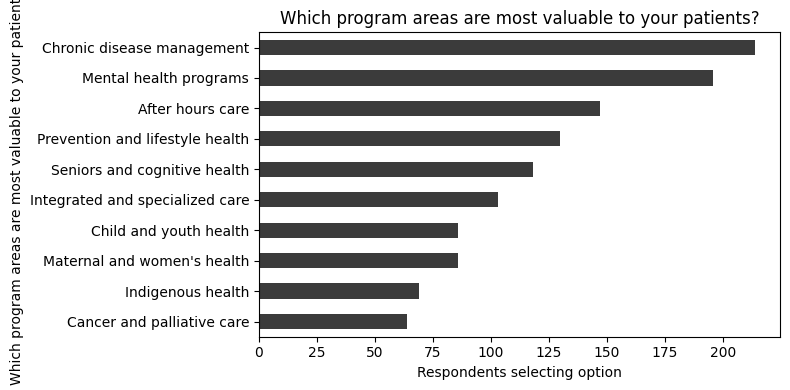

,Which program areas are most valuable to your patients?,Count,Pct of Respondents
0,Chronic disease management,214,0.556
1,Mental health programs,196,0.509
2,After hours care,147,0.382
3,Prevention and lifestyle health,130,0.338
4,Seniors and cognitive health,118,0.306


In [6]:
program_labels = {
    'PROGRAMS_C1': 'After hours care',
    'PROGRAMS_C2': 'Cancer and palliative care',
    'PROGRAMS_C3': 'Child and youth health',
    'PROGRAMS_C4': 'Chronic disease management',
    'PROGRAMS_C5': 'Seniors and cognitive health',
    'PROGRAMS_C6': 'Indigenous health',
    'PROGRAMS_C7': 'Integrated and specialized care',
    'PROGRAMS_C8': "Maternal and women's health",
    'PROGRAMS_C9': 'Mental health programs',
    'PROGRAMS_C10': 'Prevention and lifestyle health',
}
programs_summary = summarize_multiselect(
    completed, program_labels,
    'Which program areas are most valuable to your patients?')
programs_summary.head()

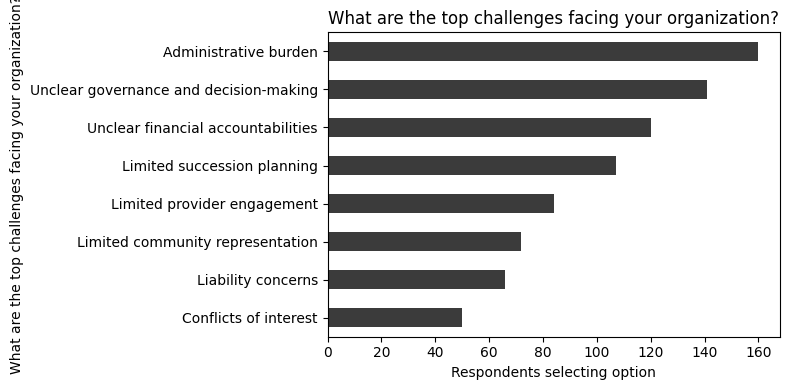

In [7]:
challenge_labels = {
    'CHALLENGES_C1': 'Administrative burden',
    'CHALLENGES_C2': 'Conflicts of interest',
    'CHALLENGES_C3': 'Liability concerns',
    'CHALLENGES_C4': 'Unclear governance and decision-making',
    'CHALLENGES_C5': 'Unclear financial accountabilities',
    'CHALLENGES_C6': 'Limited community representation',
    'CHALLENGES_C7': 'Limited provider engagement',
    'CHALLENGES_C8': 'Limited succession planning',
}
challenges_summary = summarize_multiselect(
    completed, challenge_labels,
    'What are the top challenges facing your organization?')

## 4. Likert matrix questions

Agreement matrices are best read side by side, so this function summarizes a whole battery at once and plots it as a single stacked chart. "Don't know" and "prefer not to answer" are reported but kept out of the agreement scale.

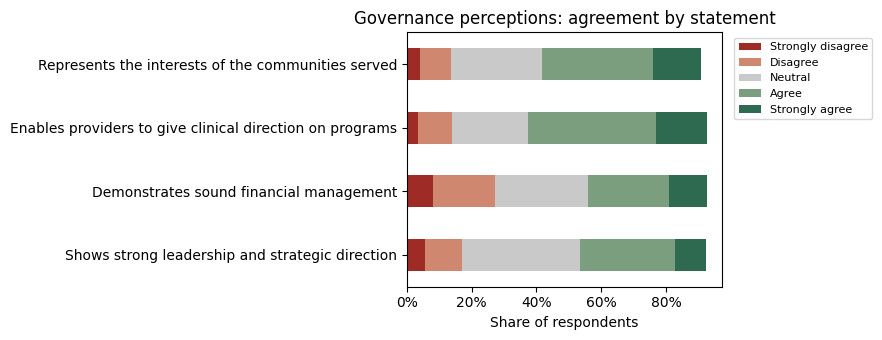

,Statement,Strongly disagree,Disagree,Neutral,Agree,Strongly agree,Don't know,Prefer not to answer
0,Represents the interests of the communities se...,0.042,0.096,0.278,0.345,0.148,0.073,0.018
1,Enables providers to give clinical direction o...,0.036,0.104,0.234,0.395,0.158,0.049,0.023
2,Demonstrates sound financial management,0.081,0.190,0.288,0.249,0.117,0.060,0.016
3,Shows strong leadership and strategic direction,0.055,0.114,0.364,0.294,0.096,0.055,0.023


In [8]:
def summarize_matrix(data, items, scale_labels):
    """Summarize a battery of Likert items into one percentage table and stacked chart."""
    rows = {}
    for col, statement in items.items():
        labelled = data[col].map(scale_labels)
        pct = labelled.value_counts(normalize=True).reindex(scale_labels.values()).fillna(0)
        rows[statement] = pct
    matrix = pd.DataFrame(rows).T.round(3)

    scale_only = [v for k, v in scale_labels.items() if k <= 5]
    colors = ['#9E2B25', '#D08770', '#C9C9C9', '#7A9E7E', '#2D6A4F']
    ax = matrix[scale_only].plot.barh(stacked=True, color=colors, figsize=(9, 3.5))
    ax.set_title('Governance perceptions: agreement by statement')
    ax.set_xlabel('Share of respondents')
    ax.xaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return matrix.reset_index(names='Statement')

matrix_items = {
    'MATRIX_A1': 'Represents the interests of the communities served',
    'MATRIX_A2': 'Enables providers to give clinical direction on programs',
    'MATRIX_A3': 'Demonstrates sound financial management',
    'MATRIX_A4': 'Shows strong leadership and strategic direction',
}
scale = {1: 'Strongly disagree', 2: 'Disagree', 3: 'Neutral', 4: 'Agree',
         5: 'Strongly agree', 6: "Don't know", 7: 'Prefer not to answer'}

matrix_summary = summarize_matrix(completed, matrix_items, scale)
matrix_summary

## 5. Export everything to one reporting workbook

Every summary table goes to its own sheet in a timestamped Excel file. This is the artifact that actually circulates: analysts and writers pull from it without rerunning any code.

In [9]:
from datetime import datetime

all_tables = {
    'Membership': member_summary,
    'Tenure': tenure_summary,
    'Community Type': community_summary,
    'Recommend': recommend_summary,
    'Valued Programs': programs_summary,
    'Top Challenges': challenges_summary,
    'Governance Matrix': matrix_summary,
}

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
file_name = f'survey_descriptive_results_{timestamp}.xlsx'

with pd.ExcelWriter(file_name) as writer:
    for sheet, table in all_tables.items():
        table.to_excel(writer, sheet_name=sheet, index=False)

print(f"Exported {len(all_tables)} summary tables to {file_name}")

Exported 7 summary tables to survey_descriptive_results_20260611_2228.xlsx


## Takeaways from this synthetic run

Chronic disease management and mental health programs lead the "most valuable" rankings, while administrative burden and unclear governance dominate the challenge list. Two thirds of respondents would recommend membership. In a real engagement, each of those findings would be paired with the open-ended evidence (see the companion sentiment triage project) before going into a briefing.

**Part 2** of this pipeline segments these results by organization size, remoteness, and region to test whether priorities differ across contexts.